In [168]:
import numpy as np
import pandas as pd
import re
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score, max_error, median_absolute_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
def calculate_metrics(y, y_pred, y_val = None, y_pred_val = None, verbose=True):
    # Calculate train metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    evs = explained_variance_score(y, y_pred)
    max_err = max_error(y, y_pred)
    medae = median_absolute_error(y, y_pred)
    metrics = {
        "mse": mse,
        "r2": r2,
        "mae": mae,
        "evs": evs,
        "max_err": max_err,
        "medae": medae
    }

    # If validation data is provided, calculate validation metrics
    if y_val is not None and y_pred_val is not None:
        # Calculate validation metrics
        mse_val = mean_squared_error(y_val, y_pred_val)
        r2_val = r2_score(y_val, y_pred_val)
        mae_val = mean_absolute_error(y_val, y_pred_val)
        evs_val = explained_variance_score(y_val, y_pred_val)
        max_err_val = max_error(y_val, y_pred_val)
        medae_val = median_absolute_error(y_val, y_pred_val)
        metrics.update({
            "mse_val": mse_val,
            "r2_val": r2_val,
            "mae_val": mae_val,
            "evs_val": evs_val,
            "max_err_val": max_err_val,
            "medae_val": medae_val
        })

        # Create a table for formatting metrics
        if verbose:
            print("Metric       |    Train     |  Validation")
            print("-------------|--------------|---------------")
            print(f"MSE          |   {mse:.2e}   |   {mse_val:.2e}")
            print(f"R²           |   {r2:.4f}     |   {r2_val:.4f}")
            print(f"MAE          |   {mae:.2e}   |   {mae_val:.2e}")
            print(f"EVS          |   {evs:.4f}     |   {evs_val:.4f}")
            print(f"Max Error    |   {max_err:.2e}   |   {max_err_val:.2e}")
            print(f"Median AE    |   {medae:.2e}   |   {medae_val:.2e}")
            print()
            
    elif verbose:
        print(f"MSE          |   {mse:.2e}   ")
        print(f"R²           |   {r2:.4f}     ")
        print(f"MAE          |   {mae:.2e}   ")
        print(f"EVS          |   {evs:.4f}     ")
        print(f"Max Error    |   {max_err:.2e}   ")
        print(f"Median AE    |   {medae:.2e}   ")
        print()
    
    # Return metrics in a dictionary for reporting
    return metrics

In [170]:
df_train = pd.read_csv('../data/train/transformed_train.csv')
X_train = df_train.drop(columns=["Precio"])
y_train = df_train["Precio"]

df_val = pd.read_csv('../data/train/transformed_val.csv')
X_val = df_val.drop(columns=["Precio"])
y_val = df_val["Precio"]

In [171]:
params = {
    "subsample": 1.0,
    "reg_lambda": 1,
    "reg_alpha": 0.01,
    "n_estimators": 600,
    "max_depth": 6,
    "learning_rate": 0.1,
    "gamma": 0,
    "colsample_bytree": 0.6,
    "random_state": 42,
}

model = XGBRegressor(**params)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

metrics = calculate_metrics(y_train, y_pred_train, y_val, y_pred_val)

Metric       |    Train     |  Validation
-------------|--------------|---------------
MSE          |   8.60e+12   |   2.94e+13
R²           |   0.9856     |   0.9451
MAE          |   1.19e+06   |   2.70e+06
EVS          |   0.9856     |   0.9451
Max Error    |   2.14e+08   |   1.28e+08
Median AE    |   8.10e+05   |   1.49e+06



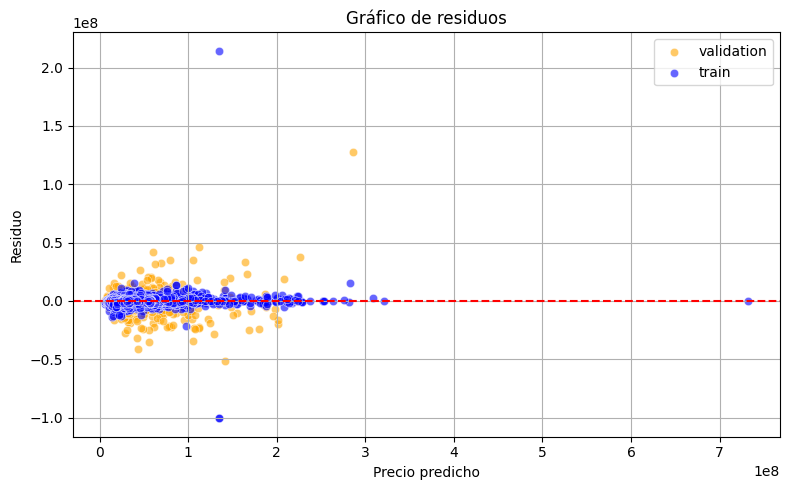

In [172]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_val, y=y_val-y_pred_val, alpha=0.6, color='orange', label='validation')
sns.scatterplot(x=y_pred_train, y=y_train - y_pred_train, alpha=0.6, color='blue', label='train')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Precio predicho")
plt.ylabel("Residuo")
plt.title("Gráfico de residuos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

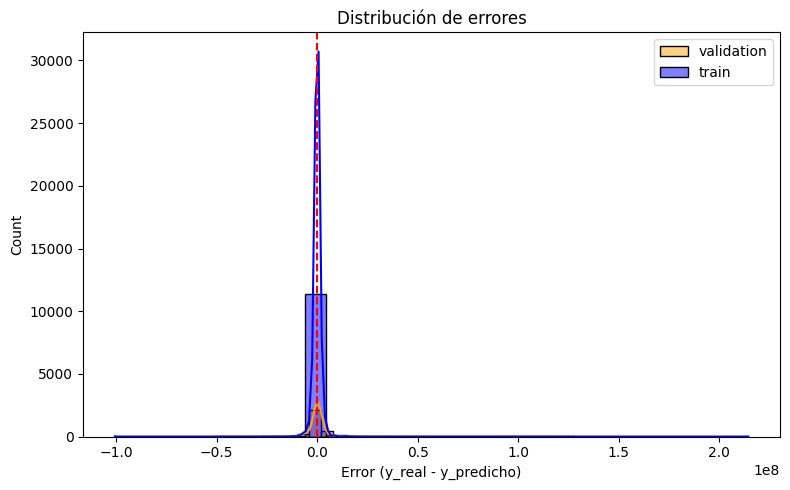

In [173]:
# 3. Distribución de errores (histograma + KDE)
plt.figure(figsize=(8, 5))
sns.histplot(y_val-y_pred_val, kde=True, bins=30, color="orange", alpha=0.5, label='validation')
sns.histplot(y_train - y_pred_train, kde=True, bins=30, color="blue", alpha=0.5, label='train')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Error (y_real - y_predicho)")
plt.title("Distribución de errores")
plt.tight_layout()
plt.legend()
plt.show()

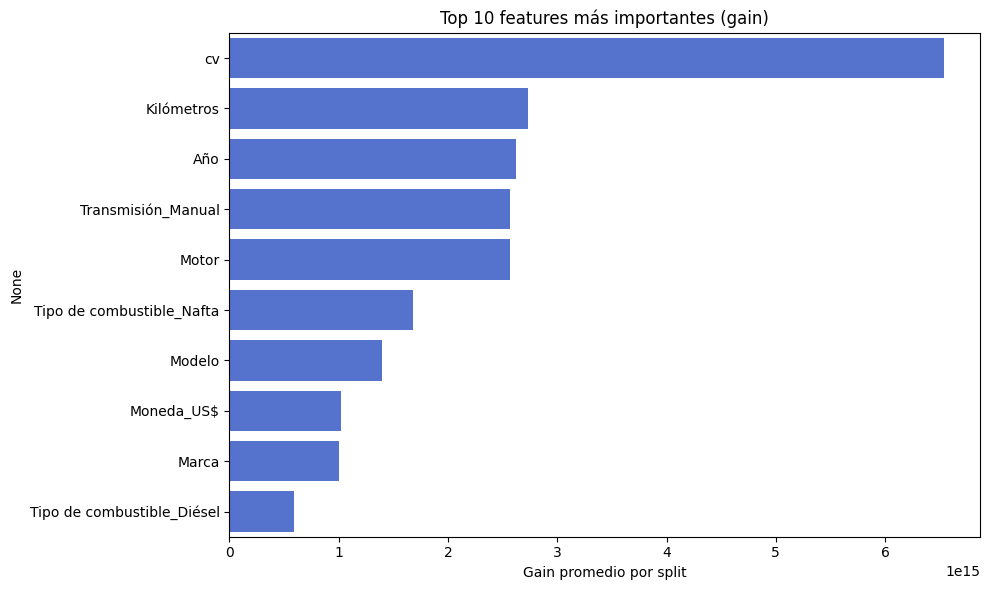

In [174]:
# 4. Importancia de variables (XGBoost) - Top 10
booster = model.get_booster()
fmap = booster.get_score(importance_type='gain')
all_features = {f: fmap.get(f, 0.0) for f in booster.feature_names}
feat_importance = pd.Series(all_features).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, color='royalblue')
plt.title("Top 10 features más importantes (gain)")
plt.xlabel("Gain promedio por split")
plt.tight_layout()
plt.show()


In [176]:
df_raw = pd.read_csv('../data/train/cleaned_train.csv')

# 1. Calcular error absoluto y ordenar
df_validation = df_val.copy()
df_validation['Predicted'] = y_pred_val
df_validation['abs_error'] = (df_validation['Precio'] - df_validation['Predicted']).abs()
df_validation_sorted = df_validation.sort_values(by='abs_error', ascending=False)

# 2. Elegir top N peores casos
top_n = 10
top_indices = df_validation_sorted.head(top_n)['idx'].values  # asumo que 'idx' está en df_validation

# 3. Buscar esos índices en df_raw
df_raw_top_errors = df_raw[df_raw['idx'].isin(top_indices)]

# 4. Mostrar datos crudos
print(f"Top {top_n} peores predicciones - datos originales sin procesar:")
display(df_raw_top_errors)

KeyError: 'idx'

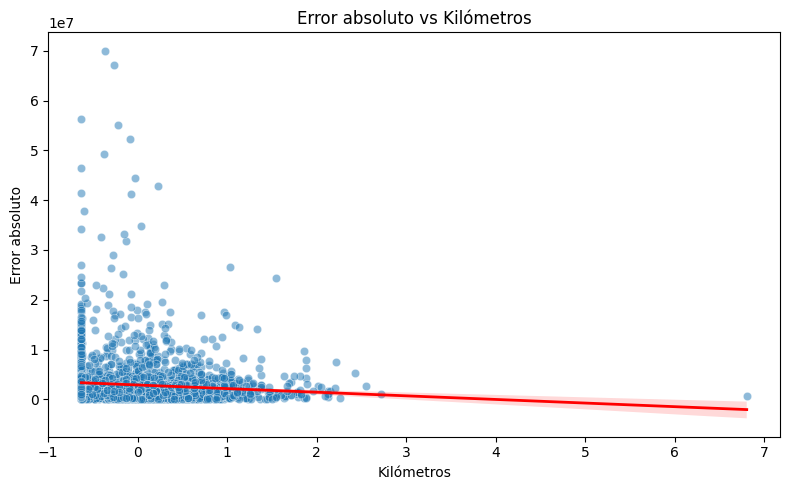

Top 10 marcas con mayor MAE (según Marca original de df_raw):
           Marca           MAE
0        Porsche  2.261756e+07
1  Mercedes-Benz  1.232598e+07
2     Mitsubishi  9.877798e+06
3            D·S  9.277424e+06
4           D.S.  7.225260e+06
5           Audi  6.725159e+06
6          Isuzu  6.648016e+06
7            GWM  6.312804e+06
8            BMW  5.934880e+06
9     Land Rover  5.601102e+06


In [ ]:
# 2. Hacer merge para levantar Marca original desde df_raw
df = df_validation.merge(df_raw[['idx', 'Marca']], on='idx', how='left', suffixes=('', '_raw'))

# 3. Gráfico error absoluto vs kilómetros
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Kilómetros', y='abs_error', alpha=0.5)
sns.regplot(data=df, x='Kilómetros', y='abs_error', scatter=False, color='red', line_kws={'linewidth':2})
plt.xlabel('Kilómetros')
plt.ylabel('Error absoluto')
plt.title('Error absoluto vs Kilómetros')
plt.tight_layout()
plt.show()

# 4. Tabla top 10 marcas con mayor RMSE usando la marca original de df_raw
rmse_por_marca = df.groupby('Marca_raw')['abs_error'].mean().sort_values(ascending=False)
top10_rmse = rmse_por_marca.head(10).reset_index()
top10_rmse.columns = ['Marca', 'MAE']

print("Top 10 marcas con mayor MAE (según Marca original de df_raw):")
print(top10_rmse)

In [166]:
# Agrupamos igual que antes
grouped = df.groupby('Marca').agg(
    MAE = ('abs_error', lambda x: np.sqrt(np.mean(x))),
    Count = ('Marca_raw', 'count')
)

# Ordenamos por cantidad de datos (descendente)
top_most_data = grouped.sort_values(by='Count', ascending=False).head(10).reset_index()

print("Top 10 marcas con más cantidad de datos y su RMSE:")
print(top_most_data)


Top 10 marcas con más cantidad de datos y su RMSE:
          Marca          MAE  Count
0  2.364476e+07  1778.146168    342
1  1.571700e+07  1208.720580    330
2  2.824417e+07  1658.200372    299
3  2.195435e+07  1470.174452    270
4  1.530751e+07  1315.760738    242
5  2.036304e+07  1610.245157    210
6  2.246936e+07  1955.984204    204
7  2.136067e+07  1324.470757    172
8  2.053501e+07  1295.462023    123
9  7.183297e+06  1393.560061    101
